<a href="https://colab.research.google.com/github/bhavyapandey696/My-Anatomy-Module--1/blob/main/COVID_19_EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-in-india' dataset.
Path to dataset files: /kaggle/input/covid19-in-india


In [ ]:
import os

print(os.listdir(path))

['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


In [ ]:
import pandas as pd
file_path = os.path.join(path, "covid_19_india.csv")
df = pd.read_csv(file_path)

In [ ]:
df.head(3)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2


In [ ]:
# understand the dataset
print("Shape",df.shape)
print("Columns", df.columns)
print("Data types", df.dtypes)

Shape (18110, 9)
Columns Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')
Data types Sno                          int64
Date                        object
Time                        object
State/UnionTerritory        object
ConfirmedIndianNational     object
ConfirmedForeignNational    object
Cured                        int64
Deaths                       int64
Confirmed                    int64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [ ]:
df.isnull().sum()

,0
Sno,0
Date,0
Time,0
State/UnionTerritory,0
ConfirmedIndianNational,0
ConfirmedForeignNational,0
Cured,0
Deaths,0
Confirmed,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3
...,...,...,...,...,...,...,...,...,...
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353
18106,18107,2021-08-11,8:00 AM,Tripura,-,-,77811,773,80660
18107,18108,2021-08-11,8:00 AM,Uttarakhand,-,-,334650,7368,342462
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [ ]:
df["Recovered"] = df["Cured"]

In [ ]:
# Create a new column
df["Active"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]

In [ ]:
# check
df.sample(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,Recovered,Active
6457,6458,2020-09-20,8:00 AM,Andhra Pradesh,-,-,530711,5302,617776,530711,81763
5916,5917,2020-09-04,8:00 AM,Manipur,-,-,4774,32,6609,4774,1803
1982,1983,2020-05-16,8:00 AM,Jharkhand,-,-,87,3,203,87,113
13379,13380,2021-04-02,8:00 AM,Manipur,-,-,28963,374,29401,28963,64
6935,6936,2020-10-03,8:00 AM,Odisha,-,-,194128,875,226334,194128,31331
17902,17903,2021-08-06,8:00 AM,Delhi,-,-,1411001,25060,1436579,1411001,518
553,554,2020-04-01,7:30 PM,Tamil Nadu,-,-,6,1,234,6,227
8968,8969,2020-11-30,8:00 AM,Rajasthan,-,-,234336,2292,265386,234336,28758
6926,6927,2020-10-03,8:00 AM,Karnataka,-,-,499506,9119,620630,499506,112005
5419,5420,2020-08-21,8:00 AM,Jammu and Kashmir,-,-,23225,578,30717,23225,6914


In [ ]:
# create our state_level summary
state_data = (
    df.groupby("State/UnionTerritory")
    [["Confirmed","Deaths","Recovered","Active"]]
    .max()
    .reset_index()

)

In [ ]:
# create rates
state_data["Recovery_Rate"] = state_data["Recovered"] / state_data["Confirmed"].replace(0,pd.NA)*100

In [ ]:
state_data["Death_Rate"] = state_data["Deaths"] / state_data["Confirmed"].replace(0,pd.NA)*100

In [ ]:
state_data.head(3)

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Andaman and Nicobar Islands,7548,129,7412,1154,98.198198,1.709062
1,Andhra Pradesh,1985182,13564,1952736,211554,98.365591,0.683262
2,Arunachal Pradesh,50605,248,47821,4465,94.498567,0.490070


In [ ]:
state_data["Recovery_Rate"] = state_data["Recovery_Rate"].round(2)
state_data["Death_Rate"] = state_data["Death_Rate"].round(2)

In [ ]:
# Top 10 affected Indian State
top10 = (
    state_data
    .sort_values("Confirmed", ascending=False)
    .head(10)
)

In [ ]:
top10

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
27,Maharashtra,6363442,134201,6159676,701614,96.80,2.11
28,Maharashtra***,6229596,130753,6000911,97932,96.33,2.10
22,Kerala,3586693,18004,3396184,445692,94.69,0.50
21,Karnataka,2921049,36848,2861499,605515,97.96,1.26
20,Karanataka,2885238,36197,2821491,27550,97.79,1.25
38,Tamil Nadu,2579130,34367,2524400,313048,97.88,1.33
1,Andhra Pradesh,1985182,13564,1952736,211554,98.37,0.68
43,Uttar Pradesh,1708812,22775,1685492,310783,98.64,1.33
45,West Bengal,1534999,18252,1506532,132181,98.15,1.19
12,Delhi,1436852,25068,1411280,103424,98.22,1.74


/tmp/ipykernel_3096/646526412.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3096/646526412.py:8: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


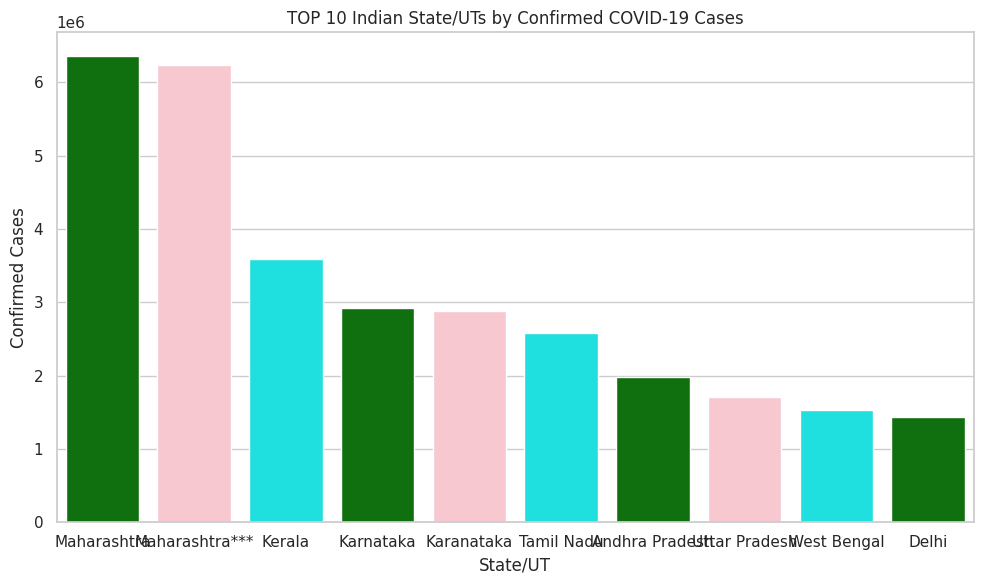

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="State/UnionTerritory",
    y="Confirmed",
    #color = "red",
    palette = ["Green","pink", "cyan"]
)

plt.title("TOP 10 Indian State/UTs by Confirmed COVID-19 Cases")
plt.xlabel("State/UT")
plt.ylabel("Confirmed Cases")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3096/2898208887.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3096/2898208887.py:9: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


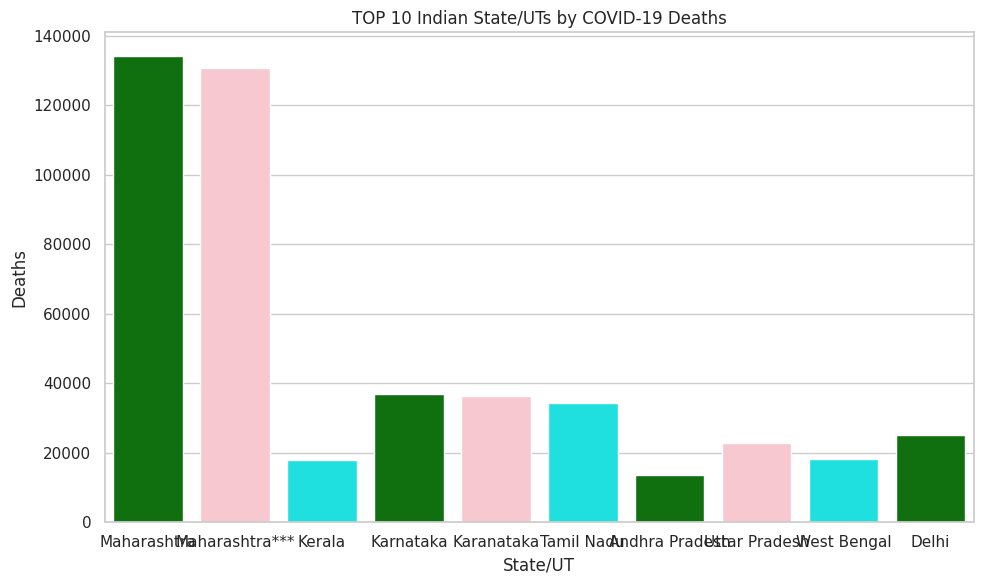

In [ ]:
# Top 10 states by deaths
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="State/UnionTerritory",
    y="Deaths",
    #color = "red",
    palette = ["Green","pink", "cyan"]
)

plt.title("TOP 10 Indian State/UTs by COVID-19 Deaths")
plt.xlabel("State/UT")
plt.ylabel("Deaths")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3096/170669346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3096/170669346.py:6: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


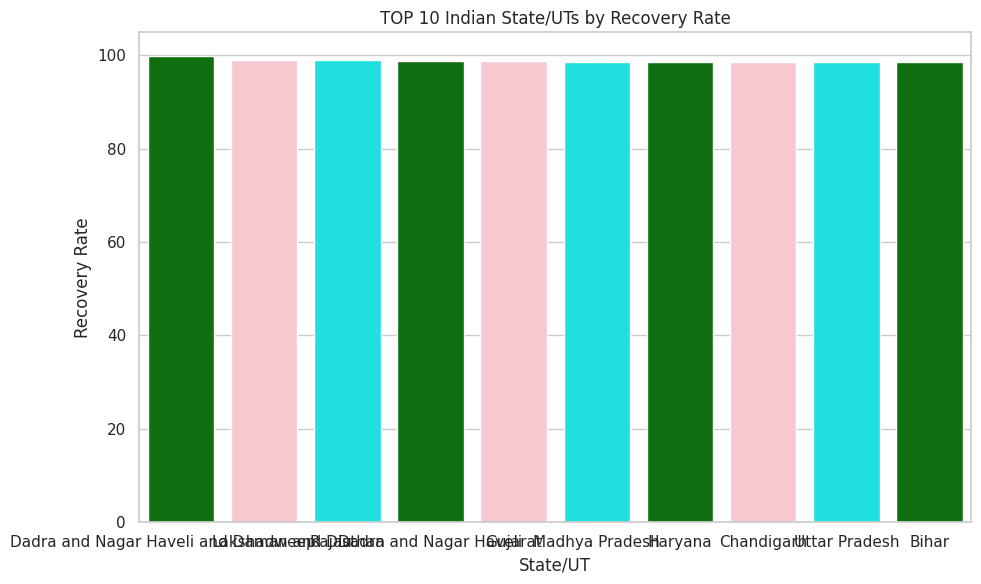

In [ ]:
# Recovery Rate vs Death Rate
rate_data = state_data.sort_values("Recovery_Rate", ascending=False).head(10
)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rate_data,
    x="State/UnionTerritory",
    y="Recovery_Rate",
    #color = "red",
    palette = ["Green","pink", "cyan"]
)

plt.title("TOP 10 Indian State/UTs by Recovery Rate")
plt.xlabel("State/UT")
plt.ylabel("Recovery Rate")

plt.tight_layout()
plt.show()

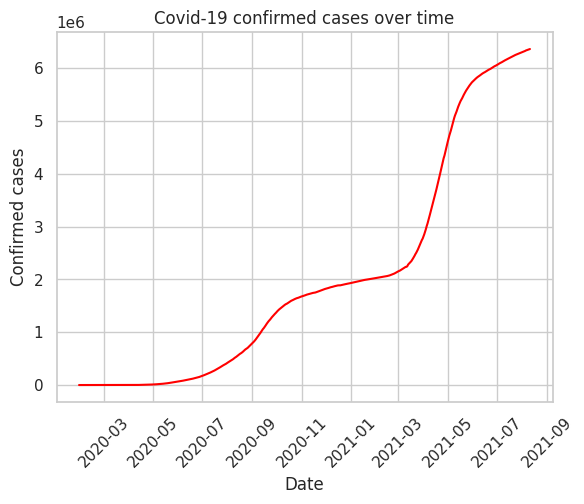

In [ ]:
daily_cases = (
    df.groupby("Date")
    ["Confirmed"]
    .max()
    .reset_index()
)
sns.lineplot(
    data= daily_cases,
    x="Date",
    y="Confirmed",
    color = "red"
)
plt.title("Covid-19 confirmed cases over time")
plt.xlabel("Date")
plt.ylabel("Confirmed cases")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.barplot(
    data=state_data.sort_values("Confirmed", ascending=False).head(15),
    x="Province/State",
    y="Confirmed"
)

plt.title("Top 15 States/Provinces by Confirmed COVID-19 Cases")
plt.xlabel("Province/State")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

In [ ]:
data = {
    "Employees": ["E01","E02","E03","E04","E05","E06","E07","E08","E09","E10"],
    "Salary": [28,30000,32000,32000,36000,40000,42000,45000,150000,250000]
}
df = pd.DataFrame(data)
df

,Employees,Salary
0,E01,28
1,E02,30000
2,E03,32000
3,E04,32000
4,E05,36000
5,E06,40000
6,E07,42000
7,E08,45000
8,E09,150000
9,E10,250000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Employees  10 non-null     object
 1   Salary     10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes


In [ ]:
df["Salary"].sort_values()

,Salary
0,28000
1,30000
2,32000
3,32000
4,36000
5,40000
6,42000
7,45000
8,48000
9,250000


In [ ]:
mean_salary = df["Salary"].mean()
print("Mean Salary:", mean_salary)

Mean Salary: 58300.0


In [ ]:
median_salary = df["Salary"].median()
print("Median Salary:", median_salary)

Median Salary: 38000.0


In [ ]:
# Mode = most frequently occuring value
mode_salary = df["Salary"].mode()
print("Mode Salary:", mode_salary)

Mode Salary: 0    32000
Name: Salary, dtype: int64


In [ ]:
# Range = Maximum - Minimum
salary_range = df["Salary"].max() - df["Salary"].min()
print("Salary Range:", salary_range)

Salary Range: 222000


In [ ]:
# Variance ask: how much do the values vary around the mean?
# variance^2 = (data point - mean)^2/ N(total number of data points)
# Company A = 30k, 31k, 32k, 33k, 34k
# Company B = 10k, 20k, 32k, 44k, 54k

variance = df["Salary"].var()
print("Variance:", variance)


Variance: 4581344444.444445


In [ ]:
# Standard Deviation = Square root of variance
std_salary = df["Salary"].std()
print("Standard Deviation:", std_salary)

Standard Deviation: 67685.6295268386


In [ ]:
# Percentiles
# Instead of asking only for the average what is I want to know where a
# particular percentage of employees fall

print("50th percentile",
      df["Salary"].quantile(0.50))


50th percentile 38000.0


In [ ]:
q1 = df["Salary"].quantile(0.25)
q2 = df["Salary"].quantile(0.50)
q3 = df["Salary"].quantile(0.75)
print("Q1",q1)
print("Q2",q2)
print("Q3",q3)

Q1 32000.0
Q2 38000.0
Q3 44250.0


In [ ]:
iqr = q3 - q1

In [ ]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Lower bound", lower_bound)
print("Upper bound", upper_bound)

# Find the outliers

outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
print("Outliers", outliers)

Lower bound 13625.0
Upper bound 62625.0
Outliers   Employees  Salary
9       E10  250000


In [ ]:
df.describe()

<Axes: xlabel='Salary', ylabel='Count'>

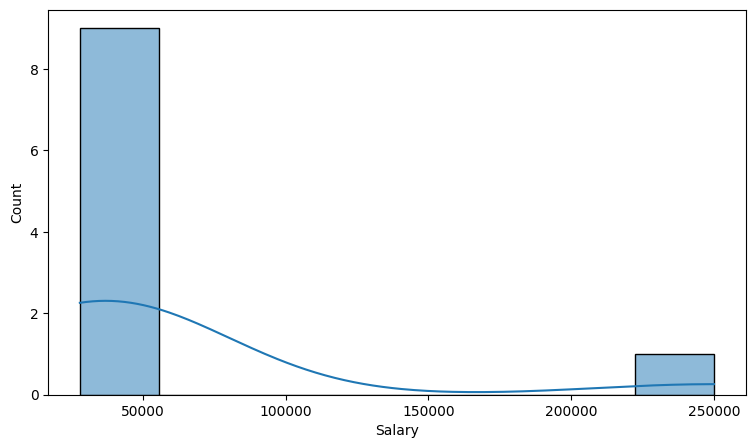

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))
sns.histplot(
    df["Salary"],
    bins = 8,
    kde = True
)


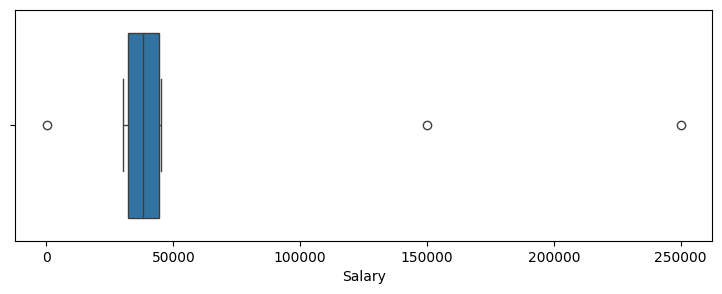

In [ ]:
plt.figure(figsize=(9,3))
sns.boxplot(x=df["Salary"])
plt.show()

In [ ]:
import numpy as np

result = np.random.choice(["Heads","Tails"])
print(result)

Heads


In [ ]:
# 20 Coin tosses
flips = np.random.choice(["Heads","Tails"], size=20)
print(flips)



['Heads' 'Tails' 'Heads' 'Heads' 'Heads' 'Tails' 'Heads' 'Heads' 'Tails'
 'Tails' 'Heads' 'Tails' 'Heads' 'Tails' 'Heads' 'Heads' 'Heads' 'Heads'
 'Heads' 'Tails']


In [ ]:
# Count Heads
heads = np.sum(flips == "Heads")
tails = np.sum(flips == "Tails")
print("Heads:", heads)
print("Tails:", tails)

Heads: 13
Tails: 7


In [ ]:
experimental_probability = heads/20
print("Experimental probability of Heads", experimental_probability)

Experimental probability of Heads 0.65


In [ ]:
import pandas as pd
data = {
    "Customer": range(1,16),
    "Visited_Before": ["Yes","No","No","No","Yes",
                       "Yes","Yes","Yes","No","Yes",
                       "Yes","Yes","Yes","No","Yes"
                       ],

    "Added_to_Cart": ["Yes","Yes","No","No","Yes",
                      "No","Yes","Yes","Yes","Yes",
                      "No","Yes","No","No","Yes"],

    "Purchased": ["Yes","Yes","No","No","Yes",
                  "No","Yes","Yes","Yes","Yes",
                  "No","Yes","No","No","Yes"]
}

customer_df = pd.DataFrame(data)
customer_df

,Customer,Visited_Before,Added_to_Cart,Purchased
0,1,Yes,Yes,Yes
1,2,No,Yes,Yes
2,3,No,No,No
3,4,No,No,No
4,5,Yes,Yes,Yes
5,6,Yes,No,No
6,7,Yes,Yes,Yes
7,8,Yes,Yes,Yes
8,9,No,Yes,Yes
9,10,Yes,Yes,Yes


In [ ]:
purchase_probability = (
    customer_df["Purchased"]  == "Yes"
).mean()

print(purchase_probability)

0.6


In [ ]:
# customer_df["Purchased"]  == "Yes"  returns True, False, ........
# Python treats True = 1  & False = 0
# so .mean() gives us the propoation.

In [ ]:
# Q: What is the probability of purchase given that he customer added something to cart?
cart_customers = customer_df[
    customer_df["Added_to_Cart"] == "Yes"
]

cart_customers

,Customer,Visited_Before,Added_to_Cart,Purchased
0,1,Yes,Yes,Yes
1,2,No,Yes,Yes
4,5,Yes,Yes,Yes
6,7,Yes,Yes,Yes
7,8,Yes,Yes,Yes
8,9,No,Yes,Yes
9,10,Yes,Yes,Yes
11,12,Yes,Yes,Yes
14,15,Yes,Yes,Yes


In [ ]:
purchase_given_cart = (
    cart_customers["Purchased"] == "Yes"
).mean()

print(purchase_given_cart)

1.0
